In [ ]:
import random
import time
import matplotlib.pyplot as plt


def search_rotated(arr, target):

    low = 0
    high = len(arr) - 1

    while low <= high:

        mid = (low + high) // 2

        if arr[mid] == target:
            return mid

        # Left half is sorted
        if arr[low] <= arr[mid]:

            if arr[low] <= target < arr[mid]:
                high = mid - 1
            else:
                low = mid + 1

        # Right half is sorted
        else:

            if arr[mid] < target <= arr[high]:
                low = mid + 1
            else:
                high = mid - 1

    return -1



sizes = list(range(1000, 100001, 5000))

avg_times = []
runs = 20
repetitions=10000

for size in sizes:


    arr = list(range(size))


    rotation = random.randint(1, size - 1)
    arr = arr[rotation:] + arr[:rotation]


    target = -1

    total_time = 0

    for _ in range(runs):

        start = time.perf_counter_ns()

        for _ in range(repetitions):
          search_rotated(arr, target)

        end = time.perf_counter_ns()

        total_time += (end - start)/repetitions

    avg_times.append(total_time / runs)

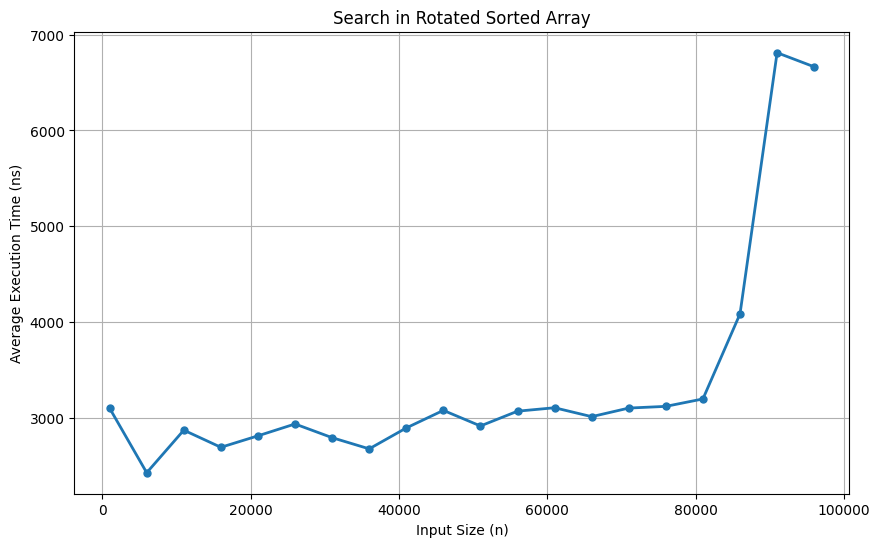

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    avg_times,
    marker='o',
    linewidth=2,
    markersize=5
)

plt.title("Search in Rotated Sorted Array")
plt.xlabel("Input Size (n)")
plt.ylabel("Average Execution Time (ns)")
plt.grid(True)

plt.show()